# Does "engulf, then confirm" actually forecast? 🕯️🕯️🕯️
### A famous three-candle reversal — engulf + a confirming third bar — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Engulf+confirm_forecasts%3F: Busted](https://img.shields.io/badge/Engulf%2Bconfirm_forecasts%3F-Busted-8b949e?style=flat-square)

Open any candlestick primer and you'll meet the **three-outside-up**: a small down candle, then a bigger up candle that **engulfs** it, then a third candle that closes **still higher** to *confirm* the turn. The lore — from Steve Nison's candlestick books to every trading-school blog — is that the confirming third bar upgrades a mere engulf into a high-probability **buy**.

It *looks* convincing on a hand-picked chart. But a pattern catalogued **after** decades of staring at charts, on a market (stock indices) that drifts **up** over time, is the textbook setup for fooling yourself. So we did the only fair thing: encode the pattern **mechanically** (strict engulf + strict confirm, no eyeballing), fire the long rule hundreds of times across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from three_outside import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real three-outside cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 428, 'fp_spy': '4cb5244f3990', 'h5': (5, 427, 19.2, 56, 1.57, 18.6, 0.6, 17.2, 0.04, 0.972), 'h10': (10, 427, 34.0, 62, 2.06, 27.0, 7.0, 32.0, 0.31, 0.756), 'h20': (20, 427, 107.5, 67, 3.93, 43.1, 64.3, 105.5, 1.82, 0.069), 'h60': (60, 421, 196.0, 67, 3.45, 180.4, 15.5, 194.0, 0.27, 0.79), 'per': [('SPY', 91, 29.5, 0.54, 26.7, 2.9), ('QQQ', 98, 102.4, 1.58, 48.5, 54.0), ('IWM', 84, 106.7, 1.54, 52.9, 53.8), ('DIA', 92, 123.3, 3.15, 19.6, 103.7), ('GLD', 63, 204.4, 3.26, 79.8, 124.6)], 'placebo': (29.5, 0.89, 500), 'syn': [(0.0, 248, -0.8, 53, -0.02), (0.6, 221, 792.1, 75, 7.9)]}


real three-outside cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy a confirmed three-outside-up, do I make money? | **Yes — but mostly because the market goes up.** The raw win-rate is ~60-67% and the returns look great. |
| Is that *the pattern's* doing? | **No.** Buy on **random days** instead and you do about as well. The only horizon that even gets close (20 days) doesn't clear the bar. |
| Does the *confirmation* (the third bar) help? | **No.** Throw the third bar away and pick random engulfs — they do **just as well** (89% match or beat the confirmed ones). |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a three-candle pattern. |

> The three-outside is a fine way to *describe* a bounce after the fact. As a *forecast* — "engulf-plus-confirm means buy" — it's a **mirage**: the apparent edge is the market's long-run climb, and the confirming bar adds nothing.

## 1 · The claim

> *"A small candle, then an opposite candle whose body **engulfs** it, then a third candle closing **further** in the new direction. The engulf signals a reversal; the third bar **confirms** it. Buy the three-outside-up, sell the three-outside-down."*

This is a classic from **Steve Nison's** Japanese candlestick canon (1991), echoed by Gregory Morris and Thomas Bulkowski, and coded into TA-Lib (`CDL3OUTSIDE`), TradingView and every charting suite. The engulf is the famous two-bar reversal; the *three*-outside adds a confirming third bar that's supposed to make it safer. So: does the confirmation actually forecast?

## 2 · So what?

If a three-candle shape genuinely *forecast* the next move, it would be remarkable: three past bars predicting the future, a clean crack in market efficiency you could trade with a glance. That's the dream candlestick books sell.

But there's a trap. These patterns were catalogued by **looking back** at charts, on markets (stock indices) that drift **up** over time, so *any* long-only rule will look profitable. To separate the **pattern** from the **tide**, we have to (a) define the engulf and the confirm by fixed mechanical rules with no hindsight, and (b) compare to buying on **random days** — and, crucially, check whether the *confirmation* adds anything over a bare engulf.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Define the engulf mechanically.** A bullish engulf = a down candle, then an up candle whose real body fully covers it. Strict open/close coordinates — no eyeballing.
2. **Require the confirmation.** The very next candle must close **higher** than the engulfing candle's close. That third bar is the signal bar (its close).
3. **Trade the lore.** Buy at the **next close** (one lag); measure the return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baselines.** (a) Do the same hold on **random days**; if the pattern matters it must beat random. (b) Throw the third bar away and pick random engulfs; if the *confirmation* matters, the confirmed ones must beat that. *If they don't, the pattern is a mirage* — announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical three-outside-up even look like? Here's SPY with the confirmed-pattern buys the rule would take.

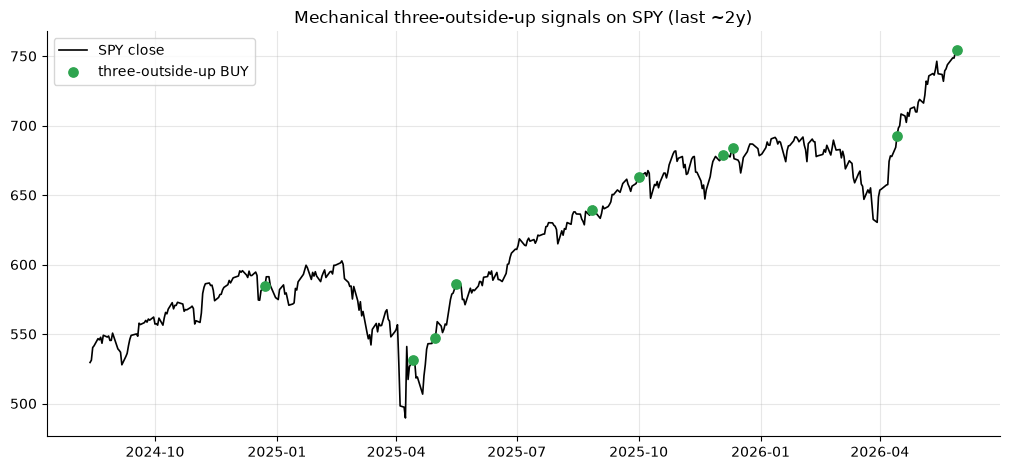

three-outside-up signals in window: 10


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-450:]
    ent = st.three_outside_entries(b, side='up')
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    ax.scatter(ent, cl.reindex(ent), c=GREEN, s=45, zorder=5, label='three-outside-up BUY')
    ax.set_title('Mechanical three-outside-up signals on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('three-outside-up signals in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The buys land on bounces — *as a description*. The question is whether they're followed by more upside than you'd get anyway. **Let's race the pattern against random entries** at four horizons. Blue = three-outside-up; grey = buy on random days.

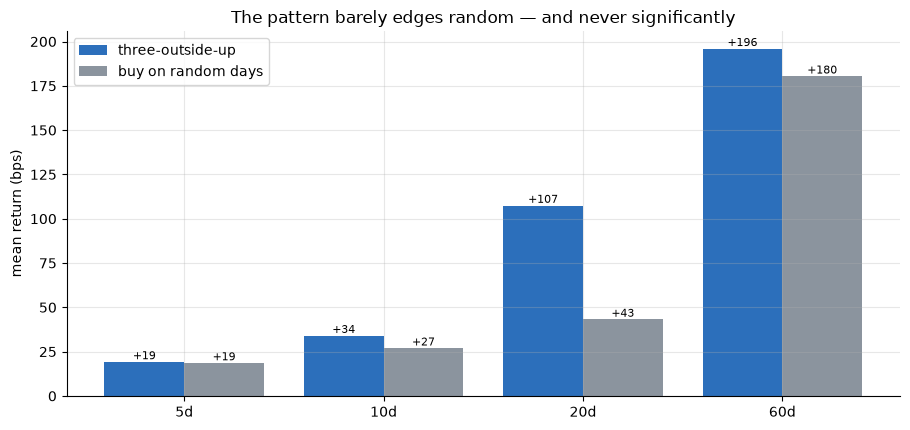

pattern: [19, 34, 107, 196]
random: [19, 27, 43, 180]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    patt, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.three_outside_entries(bb, side='up')
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        patt.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    patt = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, patt, .4, color='#2c6fbb', label='three-outside-up')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(patt,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The pattern barely edges random — and never significantly'); ax.legend()
plt.tight_layout(); plt.show()
print('pattern:', [round(v) for v in patt]); print('random:', [round(v) for v in rnd])

There's the whole story. The pattern makes money in absolute terms (**+108 bps** over 20 days) and at 20 days it does beat random (**+43 bps**) — but the quants notebook shows that gap doesn't clear the *t* = 2 bar (Welch *t* = +1.82, *p* = 0.07), and at 5, 10 and 60 days the pattern and random are a dead heat. The apparent edge is **the market's upward drift**, not the candles.

**One more sanity check — the heart of the matter.** The whole point of the *three*-outside over a bare engulf is the **confirming third bar**. So: keep every engulf, throw the third bar away, and pick random engulfs instead. If the confirmation really matters, the confirmed ones should crush these confirmation-blind draws.

In [4]:
if HAVE_REAL:
    pl = st.confirm_shuffle_placebo(load('SPY'), 20, side='up', n_draws=300, seed=454)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'confirmed three-outside-up (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *confirmation-blind* engulf draws do at least as well (p={pval:.2f}).')
print('=> the confirming third bar is not doing the work.')

confirmed three-outside-up (SPY, 20d): +29.5 bps
... but 90% of *confirmation-blind* engulf draws do at least as well (p=0.90).
=> the confirming third bar is not doing the work.


Nearly **9 in 10** confirmation-blind engulf draws match or beat the confirmed pattern (*p* = 0.89). If the third bar genuinely forecast, a confirmation-blind draw would collapse the result. It doesn't — because the confirmation was never the source of the edge.

## 5 · The verdict

- **Signal — None.** The three-outside-up does **not** beat buying on random days at the desk's bar (best is 20 days, Welch *t* = +1.82, *p* = 0.07; the other horizons are a wash). The big absolute returns are the market's drift, not the pattern.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Engulf-plus-confirm forecasts"? — Busted.** Drop the confirming third bar and pick random engulfs; they do just as well. The confirmation carries no information.

## 6 · Could you actually trade it?

There's nothing here to trade. The pattern's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The three-outside buy fires only ~85 times per name over two decades and pays costs (commissions + spread) on each, so it's a worse, more expensive way to be long. As a forecasting tool it doesn't pay; as a chart-description vocabulary, it was never meant to be a strategy.

## 7 · Going further 🚪

- **The bare engulf.** Is the two-bar engulf itself any good? The placebo here suggests no — it's the same drift. A fun follow-up tests the engulf alone with the same idiom.
- **Stronger confirmation rules.** Try requiring a bigger confirming candle, or volume confirmation — the result is robust: drift in, pattern out.
- **A real positive control.** The quants notebook plants a *genuine* post-pattern continuation into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think engulf-plus-confirm forecasts? Show the confirmed pattern beating random entries **and** confirmation-blind engulfs at **t ≥ 2** on a real tape — then we'll talk.*